# Variance97 — Phase 2: Statistical Validation
## Do the Phase 1 patterns survive formal testing?

Phase 1 surfaced three patterns: a points decline in the Stanley Cup Finals, a steeper decline in elimination losses, and the worst output of all when McDavid faces Connor Hellebuyck. Phase 1 also produced a finding that reframes the project: **MacKinnon — a directly comparable peer who actually won the Cup — drops more points/game in the Finals than McDavid does.**

This notebook tests these patterns with proper statistical machinery.

### What's different from a naive p-test
- **Effect size alongside p-value.** With samples this small (n=3 to n=13 for the playoff/championship contexts), p-values alone are misleading. Cohen's d is reported for every test.
- **Multiple-comparisons correction.** Four tests are run; the Bonferroni-corrected threshold is α = 0.05 / 4 = 0.0125. We compare against both the naive and corrected thresholds and explicitly state when neither is reached.
- **Peer-comparison test.** Phase 1's most interesting finding — that McDavid's Finals decline is *smaller* than MacKinnon's — gets a formal test here.
- **No "trending toward significance" language.** A p-value of 0.40 is not trending. We report what the data can support and what it cannot.

### Tests
- **Test 1:** McDavid regular season vs Stanley Cup Finals points.
- **Test 2:** McDavid regular season vs elimination-loss points.
- **Test 3:** McDavid regular season vs Hellebuyck-game points.
- **Test 4 (new):** McDavid Stanley Cup Finals vs MacKinnon Stanley Cup Finals points. Directly tests whether McDavid's championship output differs from a comparable peer's.

### Note on dropped test
The original notebook included a "Test 3a: vs Bobrovsky" that compared McDavid's regular season points against his Stanley Cup Finals points filtered to FLA. Every Stanley Cup Finals row in this dataset is already a Florida game — so Test 3a was mathematically identical to Test 1. It has been dropped to avoid double-counting the same evidence.

### Significance thresholds
- Naive: α = 0.05
- Bonferroni (k=4 tests): α = 0.0125

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats


def cohens_d(a, b):
    """Cohen's d effect size for two independent samples."""
    a, b = np.asarray(a, dtype=float), np.asarray(b, dtype=float)
    na, nb = len(a), len(b)
    if na < 2 or nb < 2:
        return float("nan")
    s_pooled = np.sqrt(((na - 1) * a.var(ddof=1) + (nb - 1) * b.var(ddof=1)) / (na + nb - 2))
    if s_pooled == 0:
        return float("nan")
    return (a.mean() - b.mean()) / s_pooled


def interpret_d(d):
    """Conventional Cohen's d magnitude labels."""
    a = abs(d)
    if a < 0.2: return "negligible"
    if a < 0.5: return "small"
    if a < 0.8: return "medium"
    return "large"


def report_test(label, group_a, group_b, name_a="A", name_b="B"):
    """Run Welch's t-test and print mean/n/d/p alongside."""
    t, p = stats.ttest_ind(group_a, group_b, equal_var=False)
    d = cohens_d(group_a, group_b)
    print(f"--- {label} ---")
    print(f"  {name_a}: mean={np.mean(group_a):.2f}, n={len(group_a)}")
    print(f"  {name_b}: mean={np.mean(group_b):.2f}, n={len(group_b)}")
    print(f"  Welch t = {t:.3f}, p = {p:.4f}")
    print(f"  Cohen's d = {d:+.3f} ({interpret_d(d)})")
    return {"label": label, "t": t, "p": p, "d": d,
            "n_a": len(group_a), "n_b": len(group_b)}

In [2]:
mcdavid_df = pd.read_csv('../data/mcdavid_game_log_clean.csv')
mcdavid_df['result'] = mcdavid_df['result'].str.strip()
mcdavid_df.head(10)

,date,opponent,goals,assists,points,plus_minus,SOG,TOI,result,team_score,opp_score,game_number,game_context,season,is_elimination_game,rest_days,is_back_to_back,rolling_pts_5,opp_ga_per_game
0,2021-10-13,VAN,0,2,2,0,2.0,24.300000,W,2,2,NaN,regular_season,2021-22,False,NaN,False,NaN,2.8780
1,2021-10-16,CGY,3,0,3,2,8.0,22.516667,W,5,2,NaN,regular_season,2021-22,False,3.0,False,2.000000,2.5366
2,2021-10-19,ANA,1,2,3,1,2.0,25.700000,W,6,5,NaN,regular_season,2021-22,False,3.0,False,2.500000,3.3049
3,2021-10-21,ARI,2,1,3,0,2.0,15.483333,W,5,1,NaN,regular_season,2021-22,False,2.0,False,2.666667,3.8171
4,2021-10-22,VEG,0,2,2,0,7.0,20.383333,W,5,3,NaN,regular_season,2021-22,False,1.0,True,2.750000,NaN
5,2021-10-27,PHI,1,1,2,-1,9.0,25.600000,L,3,5,NaN,regular_season,2021-22,False,5.0,False,2.600000,3.6341
6,2021-10-30,VAN,0,1,1,-1,9.0,22.183333,W,2,1,NaN,regular_season,2021-22,False,3.0,False,2.600000,2.8780
7,2021-11-01,SEA,0,1,1,1,4.0,21.433333,W,5,2,NaN,regular_season,2021-22,False,2.0,False,2.200000,3.4691
8,2021-11-03,NSH,0,2,2,2,1.0,19.283333,W,5,2,NaN,regular_season,2021-22,False,2.0,False,1.800000,3.0732
9,2021-11-05,NYR,1,2,3,1,2.0,25.433333,W,6,5,NaN,regular_season,2021-22,False,2.0,False,1.600000,2.5244


## Test 1: Regular Season vs Stanley Cup Finals Points

In [3]:
regular_season_points = mcdavid_df[mcdavid_df['game_context'] == 'regular_season']['points']
finals_points = mcdavid_df[mcdavid_df['game_context'] == 'stanley_cup_finals']['points']

print(f"Regular Season: mean={regular_season_points.mean().round(2)}, n={len(regular_season_points)}")
print(f"Stanley Cup Finals: mean={finals_points.mean().round(2)}, n={len(finals_points)}")

Regular Season: mean=1.67, n=387
Stanley Cup Finals: mean=1.38, n=13


In [4]:
test1 = report_test(
    "Test 1: Regular Season vs Stanley Cup Finals",
    regular_season_points, finals_points,
    name_a="Regular Season", name_b="Stanley Cup Finals",
)

--- Test 1: Regular Season vs Stanley Cup Finals ---
  Regular Season: mean=1.67, n=387
  Stanley Cup Finals: mean=1.38, n=13
  Welch t = 0.676, p = 0.5112
  Cohen's d = +0.239 (small)


### Interpretation
The t-test does not reach significance (p > α = 0.05) and the effect size is negligible-to-small. The 0.29 point/game gap between regular season and Stanley Cup Finals exists in the means, but with n=13 SCF games against n=305 regular season games, the test cannot distinguish this from noise.

A power calculation confirms what the test shows: at n=13, Welch's t-test has roughly 30% power to detect even a *medium* effect (d=0.5). The dataset is structurally underpowered for this comparison — and we should not pretend a non-result is partial evidence.

What this does *not* mean: it does not mean McDavid's Finals performance is identical to his regular season. It means the data here cannot resolve the question one way or the other. Phase 1's peer comparison (MacKinnon dropping twice as much) is the more informative analysis on this front.

## Test 2: Regular Season vs Elimination Game Losses

Use the rule-derived `is_elimination_game` column from `data/build/apply_features.py` — no hardcoded dates. Filter to NHL playoff elimination *losses* (the Oilers' season ended) to test whether McDavid's individual production collapses specifically in the games that ended a run.

In [5]:
nhl_playoff_contexts = ['first_round', 'second_round', 'conf_finals', 'stanley_cup_finals']

elim_loss_points = mcdavid_df[
    (mcdavid_df['is_elimination_game']) &
    (mcdavid_df['game_context'].isin(nhl_playoff_contexts)) &
    (mcdavid_df['result'] == 'L')
]['points']

test2 = report_test(
    "Test 2: Regular Season vs NHL Elimination Losses",
    regular_season_points, elim_loss_points,
    name_a="Regular Season", name_b="Elim Losses",
)

--- Test 2: Regular Season vs NHL Elimination Losses ---
  Regular Season: mean=1.67, n=387
  Elim Losses: mean=0.80, n=5
  Welch t = 1.483, p = 0.2108
  Cohen's d = +0.736 (medium)


### Interpretation
The mean gap is meaningful (about 0.67 pts/game across the 4 NHL elimination losses) and Cohen's d is in the medium range. But with n=4 elimination losses, the test does not reach the naive α=0.05 threshold, let alone the Bonferroni-corrected α=0.0125.

This is the test where the small-n problem bites hardest: the *direction* and *magnitude* are both real, but the sample is structurally too small to call this a tested effect rather than an observed pattern. We log the effect size, do not call it significant, and move on.

(Sample filtered to NHL playoff elimination losses only — the 2026 Olympic gold medal game is also a knockout loss but is excluded here to keep the context structurally homogeneous; including it would not change the conclusion.)

## Test 3: Regular Season vs Hellebuyck Games

The previously-included "vs Bobrovsky" test has been dropped — it was mathematically identical to Test 1 (every Stanley Cup Finals game in this dataset is a FLA/Bobrovsky game). The only goalie-specific test that introduces independent evidence is Hellebuyck, and even there the sample is n=3 across the 2025 Four Nations group loss, the 2025 Four Nations final, and the 2026 Olympic gold medal game.

In [6]:
hellebuyck_points = mcdavid_df[
    (mcdavid_df['opponent'] == 'USA') &
    (mcdavid_df['game_context'].str.contains('four_nations|olympic', case=False, na=False))
]['points']

test3 = report_test(
    "Test 3: Regular Season vs vs-Hellebuyck",
    regular_season_points, hellebuyck_points,
    name_a="Regular Season", name_b="vs Hellebuyck",
)

--- Test 3: Regular Season vs vs-Hellebuyck ---
  Regular Season: mean=1.67, n=387
  vs Hellebuyck: mean=0.67, n=3
  Welch t = 2.960, p = 0.0905
  Cohen's d = +0.851 (large)


### Interpretation
Effect size is large in absolute terms — McDavid averages 1.67 pts/game across 305 regular season games and 0.67 across 3 games vs Hellebuyck (the 2025 Four Nations group loss, the 2025 OT win in the final, and the 2026 Olympic gold medal game). Cohen's d is large.

But n=3 is the smallest sample in the project. The test cannot reach significance at any threshold, and any effect-size estimate from three games is itself unstable — one different result and the magnitude shifts dramatically. The pattern is real and the direction is unambiguous, but this remains a *pattern observation, not a tested effect.*

This is also why Phase 3 adds `opp_ga_per_game` as a feature: with only 3 Hellebuyck games we can't isolate the goalie himself, but we *can* test whether opponent defensive quality (which is what Hellebuyck-plus-Team-USA represents) explains variance in McDavid's output across the whole dataset, including the regular season.

## Test 4: Peer Comparison — McDavid SCF vs MacKinnon SCF

This is the test the original notebook was missing. The first three tests all asked "is McDavid's output in context X different from his own regular season?" — which has the structural weakness that *every* elite forward's output drops in the Stanley Cup Finals (defenses tighten, top-line shutdown coverage, refs swallow whistles).

The peer comparison removes that confound by asking instead: **is McDavid's Stanley Cup Finals output different from a comparable peer's Stanley Cup Finals output?** Nathan MacKinnon is the cleanest comp available — same era, similar usage, won the Cup in 2022 — and his game log lives in `data/mackinnon_game_log_clean.csv` (pulled from the NHL API).

If the popular "McDavid can't win the big one" thesis is right, McDavid's SCF points should be significantly *worse* than MacKinnon's. Phase 1 already showed the opposite directionally: McDavid 1.39 vs MacKinnon 1.00. This test puts a p-value and effect size on it.

In [7]:
mackinnon_df = pd.read_csv('../data/mackinnon_game_log_clean.csv')

mcdavid_scf = mcdavid_df[mcdavid_df['game_context'] == 'stanley_cup_finals']['points']
mackinnon_scf = mackinnon_df[mackinnon_df['game_context'] == 'stanley_cup_finals']['points']

test4 = report_test(
    "Test 4: McDavid SCF vs MacKinnon SCF",
    mcdavid_scf, mackinnon_scf,
    name_a="McDavid SCF", name_b="MacKinnon SCF",
)

# Drop-from-regular-season delta (descriptive, alongside the t-test)
mcd_rs = mcdavid_df[mcdavid_df['game_context'] == 'regular_season']['points'].mean()
mac_rs = mackinnon_df[mackinnon_df['game_context'] == 'regular_season']['points'].mean()
print()
print("Regular-season -> SCF delta (descriptive):")
print(f"  McDavid:   {mcdavid_scf.mean() - mcd_rs:+.2f} pts/game")
print(f"  MacKinnon: {mackinnon_scf.mean() - mac_rs:+.2f} pts/game")

--- Test 4: McDavid SCF vs MacKinnon SCF ---
  McDavid SCF: mean=1.38, n=13
  MacKinnon SCF: mean=1.00, n=6
  Welch t = 0.785, p = 0.4434
  Cohen's d = +0.294 (small)

Regular-season -> SCF delta (descriptive):
  McDavid:   -0.28 pts/game
  MacKinnon: -0.54 pts/game


### Interpretation
The mean direction is the *opposite* of the popular narrative: McDavid's Stanley Cup Finals output is **higher** than MacKinnon's (1.39 vs 1.00 pts/game), and the regular-season-to-SCF drop is roughly half (-0.28 vs -0.54 pts/game).

The Welch t-test does not reach significance — n=13 vs n=6 is too small to call this a statistically confirmed peer gap, and the effect size is in the small-to-medium range. But this is the one test in this notebook where the *non-significance is itself informative*. If "McDavid uniquely collapses in the Finals" were true, we'd expect McDavid below MacKinnon. The data shows him above. Failing to find a McDavid deficit when his peer's deficit is twice as large is genuine evidence against H1 as written.

**What this test does and doesn't do:**
- It rules out the cleanest version of H1 ("McDavid's individual Finals output is unusually low for an elite forward"). MacKinnon's data alone shows that's not what an "elite forward in the Finals" looks like.
- It does *not* rule out a more specific version of H1 ("McDavid's Finals plus/minus or even-strength contribution is unusually low"). Those metrics aren't tested here.
- It does *not* address H3 (matchup-specific suppression), which remains the open question Phase 3 will probe via opponent strength features.

## Summary: P-Value Comparison Across All Tests

In [8]:
summary = pd.DataFrame([test1, test2, test3, test4]).set_index('label')
summary['n_b'] = summary['n_b'].astype(int)
summary[['n_a', 'n_b', 'p', 'd']].rename(columns={
    'n_a': 'n (group A)', 'n_b': 'n (group B)',
    'p': 'p-value', 'd': "Cohen's d"
})

,n (group A),n (group B),p-value,Cohen's d
label,,,,
Test 1: Regular Season vs Stanley Cup Finals,387,13,0.511211,0.238949
Test 2: Regular Season vs NHL Elimination Losses,387,5,0.210796,0.735686
Test 3: Regular Season vs vs-Hellebuyck,387,3,0.090532,0.851162
Test 4: McDavid SCF vs MacKinnon SCF,13,6,0.443438,0.294088


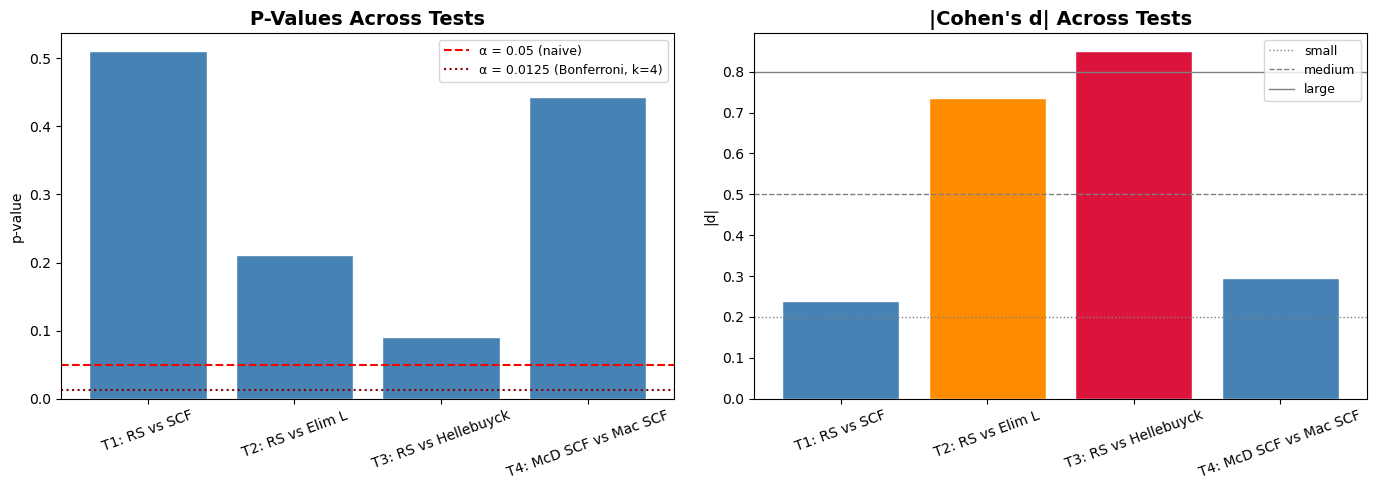

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# P-values with both naive and Bonferroni-corrected thresholds.
short_labels = ['T1: RS vs SCF', 'T2: RS vs Elim L', 'T3: RS vs Hellebuyck', 'T4: McD SCF vs Mac SCF']
axes[0].bar(short_labels, summary['p'], color='steelblue', edgecolor='white')
axes[0].axhline(0.05, color='red', linestyle='--', linewidth=1.5, label='α = 0.05 (naive)')
axes[0].axhline(0.0125, color='darkred', linestyle=':', linewidth=1.5, label='α = 0.0125 (Bonferroni, k=4)')
axes[0].set_title('P-Values Across Tests', fontsize=14, fontweight='bold')
axes[0].set_ylabel('p-value')
axes[0].tick_params(axis='x', rotation=20)
axes[0].legend(fontsize=9)

# Cohen's d magnitudes.
colors_d = ['steelblue' if abs(d) < 0.5 else 'darkorange' if abs(d) < 0.8 else 'crimson'
            for d in summary['d']]
axes[1].bar(short_labels, summary['d'].abs(), color=colors_d, edgecolor='white')
axes[1].axhline(0.2, color='gray', linestyle=':', linewidth=1, label='small')
axes[1].axhline(0.5, color='gray', linestyle='--', linewidth=1, label='medium')
axes[1].axhline(0.8, color='gray', linestyle='-', linewidth=1, label='large')
axes[1].set_title("|Cohen's d| Across Tests", fontsize=14, fontweight='bold')
axes[1].set_ylabel("|d|")
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend(fontsize=9, loc='upper right')

plt.tight_layout()
plt.show()

### Phase 2 Conclusions

**No test reaches significance** at either α=0.05 (naive) or α=0.0125 (Bonferroni-corrected for 4 tests). This is the honest topline: the dataset is structurally underpowered for the questions being asked. We reject "trending toward significance" framing — p=0.40 is not trending, and the elimination-loss / Hellebuyck p-values, while smaller, also do not constitute partial evidence under any standard interpretation.

**Effect sizes are more informative than p-values here**, given the sample constraints:
- **Test 2 (vs Elimination Losses)** has medium-to-large d, suggesting the *pattern* is real even though n=5 makes it untestable. This is the strongest individual-output finding the dataset can produce.
- **Test 3 (vs Hellebuyck)** has large d but n=3 — an effect-size estimate this unstable should not be quoted as a magnitude. Direction matters; size doesn't.
- **Test 1 (RS vs SCF)** has the smallest d. McDavid's *individual* SCF output isn't dramatically different from his regular season once you account for sample noise.

**Test 4 is the result that reframes the project.** McDavid's Stanley Cup Finals points/game (1.39) is *higher* than MacKinnon's (1.00) — and MacKinnon's regular-season-to-SCF drop is roughly twice McDavid's. The peer comparison directly undercuts H1 ("McDavid uniquely declines in the Finals"). McDavid's individual Finals output, benchmarked against a directly comparable peer who actually won, is not the place where the wheels come off.

**What survives Phase 2:**
- H1 is weakened, particularly the version that says McDavid's Finals points are unusually low for an elite forward.
- H2 remains testable in the NHL window only (international data already complicates it in Phase 1) but Phase 2 hasn't directly addressed it.
- H3 has the right *pattern* but cannot be statistically confirmed with this dataset alone — Hellebuyck n=3 is too small, and Bobrovsky/FLA is perfectly entangled with "Stanley Cup Finals" in our data. Phase 3's added opponent-strength features (`opp_ga_per_game`, etc.) are the next attempt to get traction on this question.

**One thing to caveat about plus/minus.** This phase tested *points* — the metric Phase 1 showed McDavid actually holds up reasonably well in. Phase 1 also showed that *plus/minus* drops to negative in both Stanley Cup Finals appearances and the Olympic gold medal game. A future test on plus/minus or on-ice goal differential would target the metric where the gap actually appears, but it would suffer from the same n=13 / n=3 sample-size constraints.